In [43]:
from google.colab import drive
import os

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
# Define Dataset Path
dataset_path = "/content/drive/MyDrive/Oral_cancer/First Set"

# Define Class Paths
normal_path = os.path.join(dataset_path, "100x Normal Oral Cavity Histopathological Images")
oscc_path = os.path.join(dataset_path, "100x OSCC Histopathological Images")

# Check if Paths Exist
print("Normal Path Exists:", os.path.exists(normal_path))
print("OSCC Path Exists:", os.path.exists(oscc_path))

Normal Path Exists: True
OSCC Path Exists: True


In [46]:
import cv2
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

IMG_SIZE = 160  # Resize all images to 160x160

def load_images(folder, label):
    images, labels = [], []
    for file in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, file))
        if img is not None:
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0  # Normalize
            images.append(img)
            labels.append(label)
    return images, labels

# Load images from both classes
normal_images, normal_labels = load_images(normal_path, 0)
oscc_images, oscc_labels = load_images(oscc_path, 1)

# Convert to NumPy arrays
X_normal, y_normal = np.array(normal_images), np.array(normal_labels)
X_oscc, y_oscc = np.array(oscc_images), np.array(oscc_labels)

# Check total images
print("Total Normal Images:", len(X_normal))  # Should be 89
print("Total OSCC Images:", len(X_oscc))  # Should be 439


Total Normal Images: 89
Total OSCC Images: 439


In [47]:
from imblearn.over_sampling import SMOTE

# Reshape for SMOTE (flatten images)
X_normal_flat = X_normal.reshape((X_normal.shape[0], -1))
X_oscc_flat = X_oscc.reshape((X_oscc.shape[0], -1))

# Combine the datasets
X_combined = np.vstack((X_normal_flat, X_oscc_flat))
y_combined = np.hstack((y_normal, y_oscc))

# Apply SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_combined, y_combined)

# Reshape back to images
X_resampled = X_resampled.reshape((-1, IMG_SIZE, IMG_SIZE, 3))

# Check new class distribution
print("Balanced Dataset Distribution:", np.bincount(y_resampled))


Balanced Dataset Distribution: [439 439]


In [48]:
# Split into 80% train, 10% validation, 10% test
X_train, X_temp, y_train, y_temp = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Check final dataset sizes
print("Training Data:", len(X_train), "Validation Data:", len(X_val), "Testing Data:", len(X_test))


Training Data: 702 Validation Data: 88 Testing Data: 88


In [49]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation settings
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

# Generate augmented data
train_generator = datagen.flow(X_train, y_train, batch_size=32)
val_generator = datagen.flow(X_val, y_val, batch_size=32)

In [50]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.models import Model

# Load MobileNetV2 as feature extractor
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Freeze base model
base_model.trainable = False

# Define model architecture
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = Flatten()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

# Capsule Network (ViT + CapsNet)
caps_output = Dense(2, activation="softmax")(x)  # 2 classes (Normal & OSCC)

# Build Model
model = Model(inputs, caps_output)

# Compile
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Model Summary
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     4,096,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,354,370 (24.24 MB)

 Trainable params: 4,096,386 (15.63 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [51]:
# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    batch_size=32
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 549ms/step - accuracy: 0.6525 - loss: 5.7203 - val_accuracy: 0.6364 - val_loss: 1.0067
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 187ms/step - accuracy: 0.7485 - loss: 0.5932 - val_accuracy: 0.8182 - val_loss: 0.4049
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 226ms/step - accuracy: 0.7960 - loss: 0.4084 - val_accuracy: 0.8750 - val_loss: 0.2876
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 216ms/step - accuracy: 0.8560 - loss: 0.3235 - val_accuracy: 0.9318 - val_loss: 0.2683
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step - accuracy: 0.8824 - loss: 0.2690 - val_accuracy: 0.9091 - val_loss: 0.2499
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 252ms/step - accuracy: 0.8720 - loss: 0.3015 - val_accuracy: 0.8977 - val_loss: 0.2722
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step - accuracy: 0.8772 - loss: 0.2669 - val_accuracy: 0.9091 - val_loss: 0.2583
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 186ms/step - accuracy: 0.8902 - loss: 0.1981 - val_accuracy: 0

In [ ]:
# Evaluate on Test Data
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get model predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "OSCC"], yticklabels=["Normal", "OSCC"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Print Classification Report (Precision, Recall, F1-Score)
print("Classification Report:\n", classification_report(y_test, y_pred_classes, target_names=["Normal", "OSCC"]))

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np
import cv2 # Import OpenCV
import os # Import OS
from sklearn.model_selection import train_test_split # Import train_test_split
from imblearn.over_sampling import SMOTE #Import SMOTE

# Define Dataset Path (Replace with your dataset path)
dataset_path = "/content/drive/MyDrive/Oral_cancer/First Set"

# Define Class Paths
normal_path = os.path.join(dataset_path, "100x Normal Oral Cavity Histopathological Images")
oscc_path = os.path.join(dataset_path, "100x OSCC Histopathological Images")

IMG_SIZE = 160  # Resize all images to 160x160

def load_images(folder, label):
    images, labels = [], []
    for file in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, file))
        if img is not None:
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0  # Normalize
            images.append(img)
            labels.append(label)
    return images, labels

# Load images from both classes
normal_images, normal_labels = load_images(normal_path, 0)
oscc_images, oscc_labels = load_images(oscc_path, 1)

# Convert to NumPy arrays
X_normal, y_normal = np.array(normal_images), np.array(normal_labels)
X_oscc, y_oscc = np.array(oscc_images), np.array(oscc_labels)


# Reshape for SMOTE (flatten images)
X_normal_flat = X_normal.reshape((X_normal.shape[0], -1))
X_oscc_flat = X_oscc.reshape((X_oscc.shape[0], -1))

# Combine the datasets
X_combined = np.vstack((X_normal_flat, X_oscc_flat))
y_combined = np.hstack((y_normal, y_oscc))

# Apply SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_combined, y_combined)

# Reshape back to images
X_resampled = X_resampled.reshape((-1, IMG_SIZE, IMG_SIZE, 3))

# Split into 80% train, 10% validation, 10% test
X_train, X_temp, y_train, y_temp = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


# Assuming you have y_test (true labels) and y_pred_probs (predicted probabilities)
# Get model predictions (if not already done)
y_pred = model.predict(X_test)
y_pred_probs = y_pred  # Predicted probabilities are the model's output

fpr, tpr, _ = roc_curve(y_test, y_pred_probs[:, 1])  # For OSCC class
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# Save the trained model
model.save("/content/drive/MyDrive/Oral_cancer/Final3.h5")

# Save only the weights (if needed)
model.save_weights("/content/drive/MyDrive/Oral_cancer/Final_weight3s.weights.h5") # Added '.weights' to the filename

In [52]:
model = tf.keras.models.load_model("/content/drive/MyDrive/Oral_cancer/Final.h5")

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

# Load MobileNetV2 with ImageNet weights
mobilenet_model = MobileNetV2(input_shape=(160, 160, 3), include_top=False, weights='imagenet')

# Print available layer names
for layer in mobilenet_model.layers:
    print(layer.name)


In [ ]:
layer_name = "out_relu"  # Try this first
# If it doesn't exist, use:
# layer_name = "out_relu"


In [ ]:
layer_output = mobilenet_model.get_layer(layer_name).output
print("Layer output shape:", layer_output.shape)


In [ ]:
def get_gradcam_heatmap(model, img_array, layer_name=None):
    # Access the MobileNetV2 base model
    base_model = model.get_layer('mobilenetv2_1.00_160')

    # Find the last convolutional layer if layer_name is not specified
    if layer_name is None:
        for layer in base_model.layers[::-1]:  # Iterate in reverse
            if 'conv' in layer.name.lower():
                layer_name = layer.name
                print(f"Using layer: {layer_name} for Grad-CAM")
                break
        if layer_name is None:
            raise ValueError("No convolutional layer found in the base model.")

    # Create a model that outputs the selected layer and the final output
    grad_model = tf.keras.models.Model(
        inputs=[model.input],
        outputs=[base_model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array)
        class_index = tf.argmax(predictions[0])
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_output)
    if grads is None:
        raise ValueError(f"Gradients are None for layer {layer_name}. Ensure the layer is correct.")

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_output), axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= (tf.reduce_max(heatmap) + tf.keras.backend.epsilon())
    heatmap = tf.image.resize(heatmap[..., tf.newaxis], (160, 160))
    heatmap = tf.squeeze(heatmap).numpy()

    return heatmap

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━

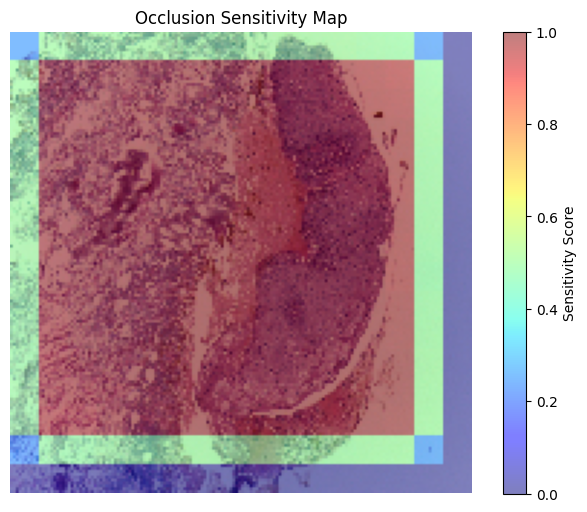

In [53]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ✅ Load trained model
model = tf.keras.models.load_model("/content/drive/MyDrive/Oral_cancer/Final.h5", compile=False)

# ✅ Preprocess input image
img_path = "/content/drive/MyDrive/Oral_cancer/First Set/100x OSCC Histopathological Images/OSCC_100x_9.jpg"
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(160, 160))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Convert to batch format
img_array /= 255.0  # Normalize

# ✅ Occlusion Parameters
patch_size = 20  # Size of occluded region
stride = 10  # Step size for occlusion
heatmap = np.zeros((160, 160))  # Heatmap to store sensitivity

# ✅ Iterate through image with occlusion
for i in range(0, 160 - patch_size, stride):
    for j in range(0, 160 - patch_size, stride):
        occluded_img = img_array.copy()
        occluded_img[:, i:i+patch_size, j:j+patch_size, :] = 0  # Black-out region

        pred = model.predict(occluded_img)[0][1]  # Probability for OSCC class
        heatmap[i:i+patch_size, j:j+patch_size] += pred  # Update heatmap

# ✅ Normalize heatmap
#heatmap /= heatmap.max()
heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap))

# ✅ Plot Occlusion Sensitivity Map
plt.figure(figsize=(8, 6))
plt.imshow(img_array[0])  # Show original image
plt.imshow(heatmap, cmap="jet", alpha=0.5)  # Overlay occlusion map
plt.colorbar(label="Sensitivity Score")
plt.title("Occlusion Sensitivity Map")
plt.axis("off")
plt.show()


In [54]:
# Save the trained model
model.save("/content/drive/MyDrive/Oral_cancer/Final2.h5")